Using device: cuda
Device Name: Tesla T4
Total GPU Count: 2
Number of classes: 10
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 201MB/s]


Activating DataParallel processing on 2 GPUs.
Epoch 1/10 -> Train Loss: 0.2788 | Train Acc: 0.9125 | Val Loss: 0.1572 | Val Acc: 0.9500
Epoch 2/10 -> Train Loss: 0.1306 | Train Acc: 0.9596 | Val Loss: 0.2680 | Val Acc: 0.9100
Epoch 3/10 -> Train Loss: 0.0812 | Train Acc: 0.9729 | Val Loss: 0.1849 | Val Acc: 0.9360
Epoch 4/10 -> Train Loss: 0.0757 | Train Acc: 0.9759 | Val Loss: 0.1033 | Val Acc: 0.9680
Epoch 5/10 -> Train Loss: 0.0497 | Train Acc: 0.9833 | Val Loss: 0.1888 | Val Acc: 0.9400
Epoch 6/10 -> Train Loss: 0.0723 | Train Acc: 0.9754 | Val Loss: 0.1046 | Val Acc: 0.9650
Epoch 7/10 -> Train Loss: 0.0578 | Train Acc: 0.9811 | Val Loss: 0.0824 | Val Acc: 0.9710
Epoch 8/10 -> Train Loss: 0.0492 | Train Acc: 0.9838 | Val Loss: 0.1367 | Val Acc: 0.9530
Epoch 9/10 -> Train Loss: 0.0435 | Train Acc: 0.9846 | Val Loss: 0.0742 | Val Acc: 0.9740
Epoch 10/10 -> Train Loss: 0.0209 | Train Acc: 0.9929 | Val Loss: 0.0310 | Val Acc: 0.9860
Model saved successfully as 'tomato_densenet121.pth'


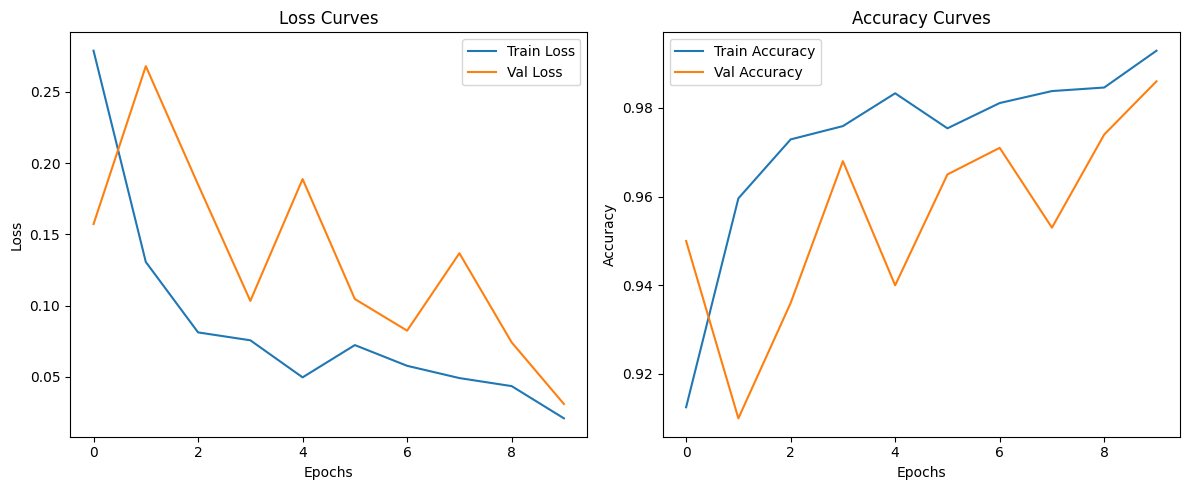


Overall Validation Accuracy: 98.60%

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.99      0.99       100
                        Tomato___Early_blight       0.99      0.95      0.97       100
                         Tomato___Late_blight       0.98      0.98      0.98       100
                           Tomato___Leaf_Mold       0.96      1.00      0.98       100
                  Tomato___Septoria_leaf_spot       1.00      1.00      1.00       100
Tomato___Spider_mites Two-spotted_spider_mite       0.98      0.98      0.98       100
                         Tomato___Target_Spot       1.00      0.97      0.98       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      1.00      0.99       100
                 Tomato___Tomato_mosaic_virus       0.99      1.00      1.00       100
                             Tomato___healthy       1.00      0.99  

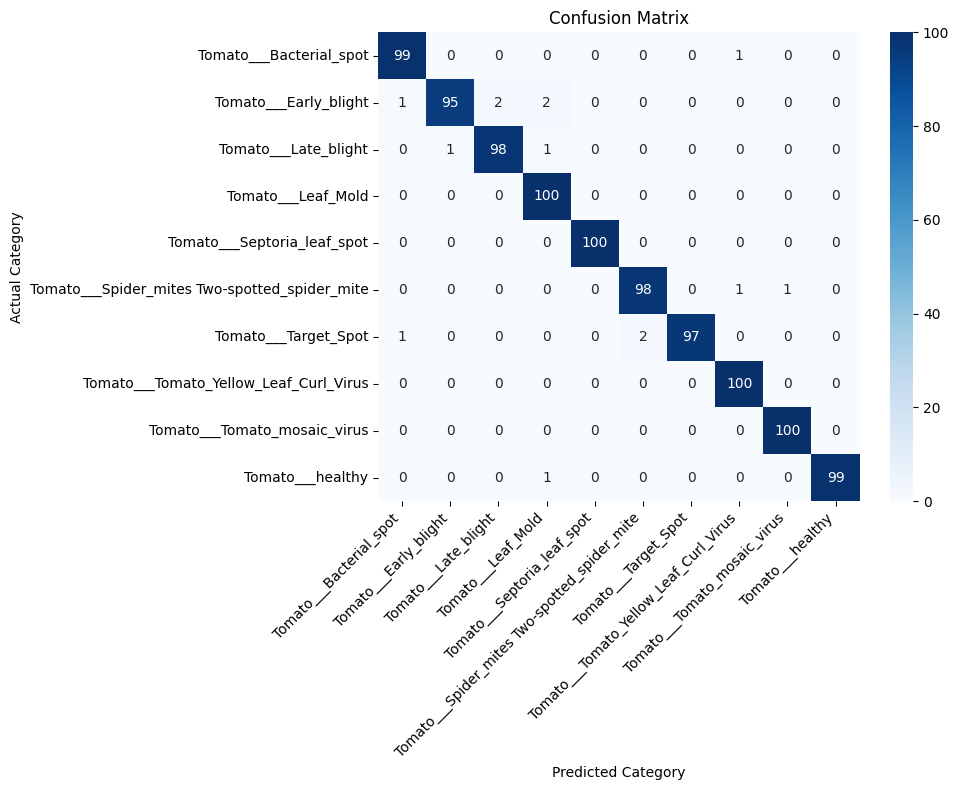


Running Inference on 10 Random Images from the Dataset...


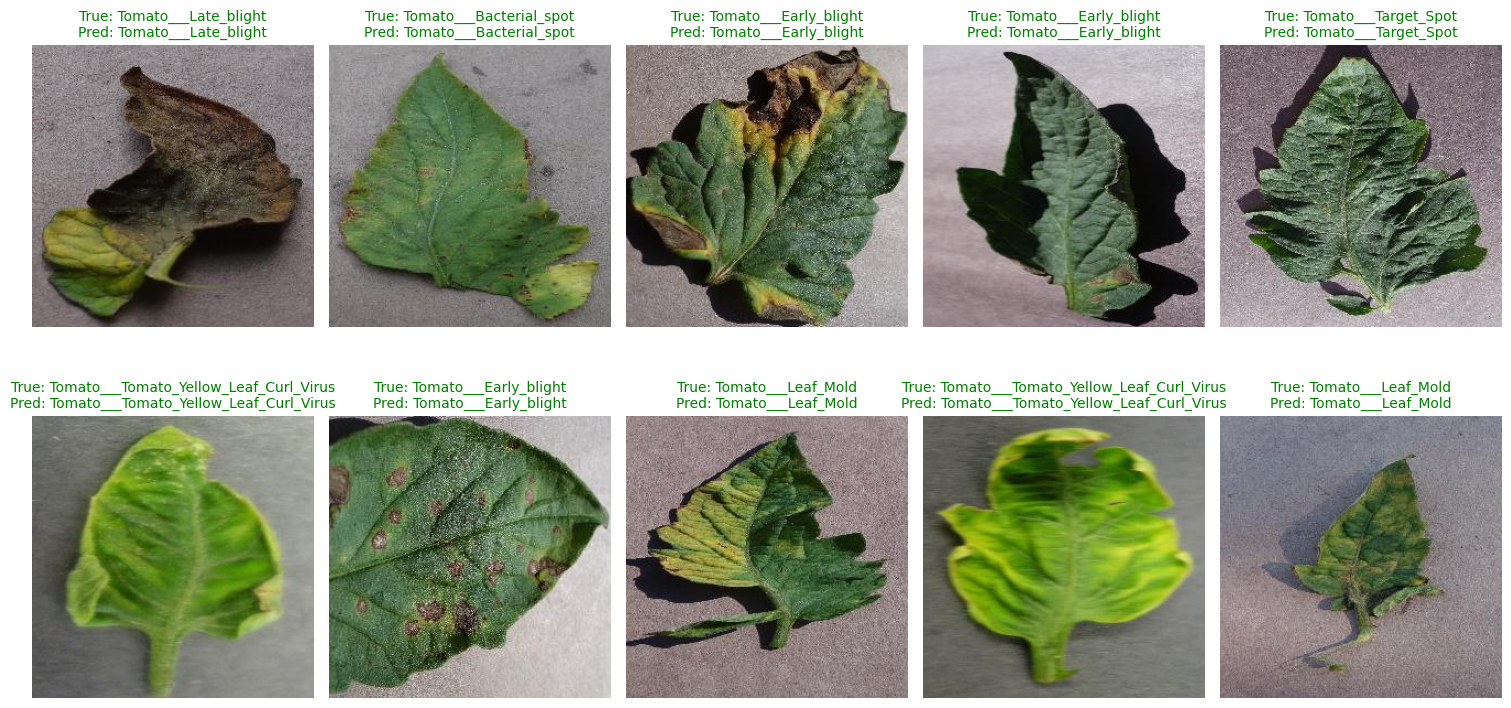

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. SETTINGS & HYPERPARAMETERS
# ==========================================
TRAIN_DIR = "/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/train"
VAL_DIR = "/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/val"

BATCH_SIZE = 64  # Increased batch size to leverage dual GPUs
EPOCHS = 10
LEARNING_RATE = 0.001
IMAGE_SIZE = 224

# Device Configuration for Kaggle T4x2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU Count: {torch.cuda.device_count()}")

# ==========================================
# 2. DATA PREPARATION & AUGMENTATION
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# ==========================================
# 3. MODEL INITIALIZATION (DENSENET121)
# ==========================================
# Load pre-trained DenseNet121
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

# Modify the final classification layer to match our dataset's classes
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, num_classes)

# Multi-GPU support wrapping
if torch.cuda.device_count() > 1:
    print(f"Activating DataParallel processing on {torch.cuda.device_count()} GPUs.")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 4. TRAINING & VALIDATION LOOP
# ==========================================
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)
    
    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc.cpu().item())
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.cpu().item())
    
    print(f"Epoch {epoch+1}/{EPOCHS} -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

# ==========================================
# 5. SAVE THE MODEL
# ==========================================
# Unwrap DataParallel structure if saving weights directly
model_to_save = model.module if isinstance(model, nn.DataParallel) else model
torch.save(model_to_save.state_dict(), "tomato_densenet121.pth")
print("Model saved successfully as 'tomato_densenet121.pth'")

# ==========================================
# 6. EVALUATION METRICS & PLOTS
# ==========================================
# Plot Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Generate predictions for the evaluation report
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Print Accuracy & Classification Report
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nOverall Validation Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot Confusion Matrix using Seaborn
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# 7. TEST WITH 10 RANDOM IMAGES
# ==========================================
print("\nRunning Inference on 10 Random Images from the Dataset...")

# Combine all valid image paths from the validation directory
all_img_paths = []
for root, dirs, files in os.walk(VAL_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_img_paths.append(os.path.join(root, file))

random_samples = random.sample(all_img_paths, 10)

# Transformation pipeline specifically for processing single display images
inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

plt.figure(figsize=(15, 8))

for idx, img_path in enumerate(random_samples):
    # Get true label from directory name
    true_label_name = os.path.basename(os.path.dirname(img_path))
    
    # Open and process image
    img = Image.open(img_path).convert('RGB')
    input_tensor = inference_transform(img).unsqueeze(0).to(device)
    
    # Run Inference
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        _, pred_idx = torch.max(output, 1)
        pred_label_name = class_names[pred_idx.item()]
        
    # Plot results
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    color = 'green' if pred_label_name == true_label_name else 'red'
    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()